In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge


In [78]:
data_path = "./data/Bike_rental_modified.csv"
df = pd.read_csv(data_path)


In [79]:
columns = [ 'instant', 'season', 'yr', 'mnth', 'holiday',
       'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum',
       'windspeed']
X = df[columns] #training features
y = df["cnt"] #training features

In [80]:
# Aufteilung in trainings- und Validierungsdaten
X_train = X[:int(0.8*len(X))]
X_valid = X[int(0.8*len(X)):]

y_train = y[:int(0.8*len(y))]
y_valid = y[int(0.8*len(y)):]

In [81]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import Normalizer

In [82]:
# Preprocessing
enc_features = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday']
num_features = ['weathersit', 'temp', 'atemp', 'hum', 'windspeed']

enc = OneHotEncoder(sparse_output=False, handle_unknown= "ignore")
X_train_enc = enc.fit_transform(X_train[enc_features])
X_train_enc = pd.DataFrame(X_train_enc, columns= enc.get_feature_names_out(enc_features))

X_valid_enc = enc.transform(X_valid[enc_features])
X_valid_enc = pd.DataFrame(X_valid_enc, columns= enc.get_feature_names_out(enc_features))

scaler = MaxAbsScaler()
X_train_scale = scaler.fit_transform(X_train[num_features])
X_train_scale = pd.DataFrame(X_train_scale, columns=num_features)

X_valid_scale = scaler.transform(X_valid[num_features])
X_valid_scale = pd.DataFrame(X_valid_scale, columns=num_features)

X_train_final = pd.concat((X_train_enc, X_train_scale), axis=1)
X_vaild_final = pd.concat((X_valid_enc, X_valid_scale), axis=1)

In [83]:
alpha_values = np.logspace(-6, 6, num=80)
gamma_values = np.logspace(-4, 4, num=20)

param_grid = {"alpha":  alpha_values}
kernel_param_grid = {"alpha":  alpha_values, "gamma": gamma_values}

Linear Model: Ridge

In [84]:
model_ridge = Ridge()
ridge_search_cv = GridSearchCV(model_ridge, param_grid, cv = 5, verbose= 3, scoring = "neg_mean_squared_error", return_train_score= True)

In [85]:
%%capture
ridge_search_cv.fit(X_train,y_train)

Linear Modell: Lasso 

In [86]:
model_lasso = Lasso()
lasso_search_cv = GridSearchCV(model_lasso, param_grid, cv = 5, verbose= 3, scoring = "neg_mean_squared_error", return_train_score= True)

In [87]:
%%capture
lasso_search_cv.fit(X_train,y_train)

Linear Model: Kernel Ridge

In [88]:

model_kernelridge = KernelRidge(kernel= "rbf")
kernelridge_search_cv = GridSearchCV(model_kernelridge, kernel_param_grid, cv = 5, verbose= 3, scoring = "neg_mean_squared_error", return_train_score= True)

In [89]:
%%capture
kernelridge_search_cv.fit(X_train,y_train)

In [ ]:
ridge_cv_results = pd.DataFrame(ridge_search_cv.cv_results_)
lasso_cv_results = pd.DataFrame(lasso_search_cv.cv_results_)
kernelridge_cv_results = pd.DataFrame(kernelridge_search_cv.cv_results_)

Grafische Darstellung

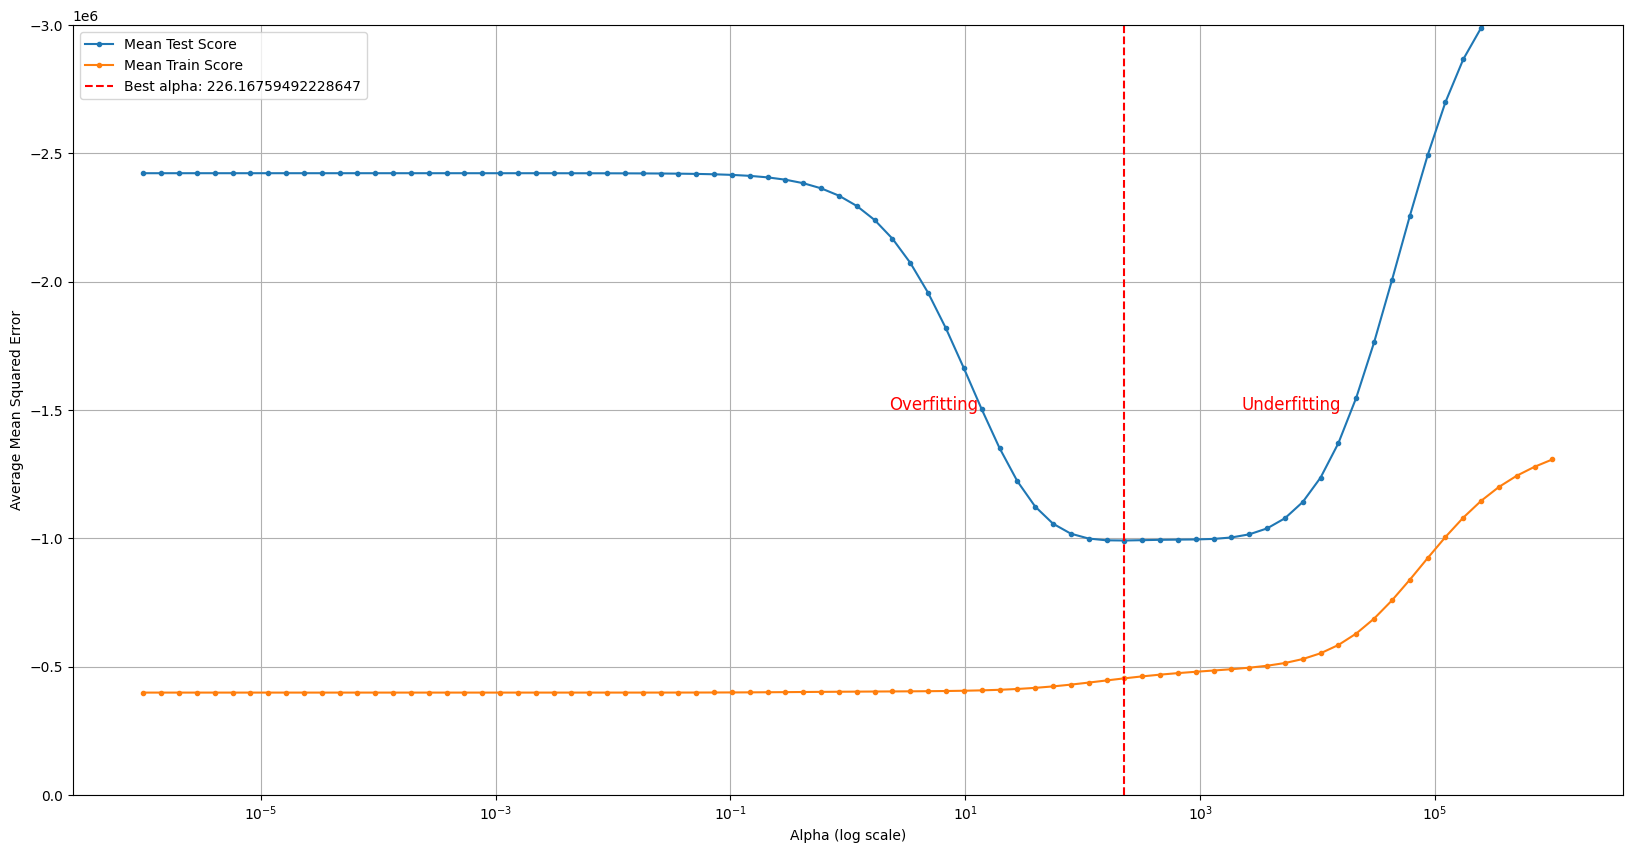

In [112]:
# Ridge
best_alpha_ridge = ridge_search_cv.best_params_["alpha"]

fig, ax = plt.subplots(1, figsize=(20,10))
ax.plot(param_grid["alpha"], ridge_cv_results["mean_test_score"], marker = ".",label = "Mean Test Score")
ax.plot(param_grid["alpha"], ridge_cv_results["mean_train_score"], marker = ".",label = "Mean Train Score")
ax.set_xscale("log")
ax.set_ylim([0, -3e6])
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Average Mean Squared Error")
ax.legend(["Mean Test Score", "Mean Train Score"], loc="best")
ax.grid()
if best_alpha_ridge is not None:
    ax.axvline(best_alpha_ridge, color="red", linestyle="--", label=f"Best alpha: {best_alpha_ridge}")
    ax.text(best_alpha_ridge/100, -1.5e6, "Overfitting", color="red", fontsize=12)
    ax.text(best_alpha_ridge*10, -1.5e6, "Underfitting", color="red", fontsize=12)
    ax.legend()

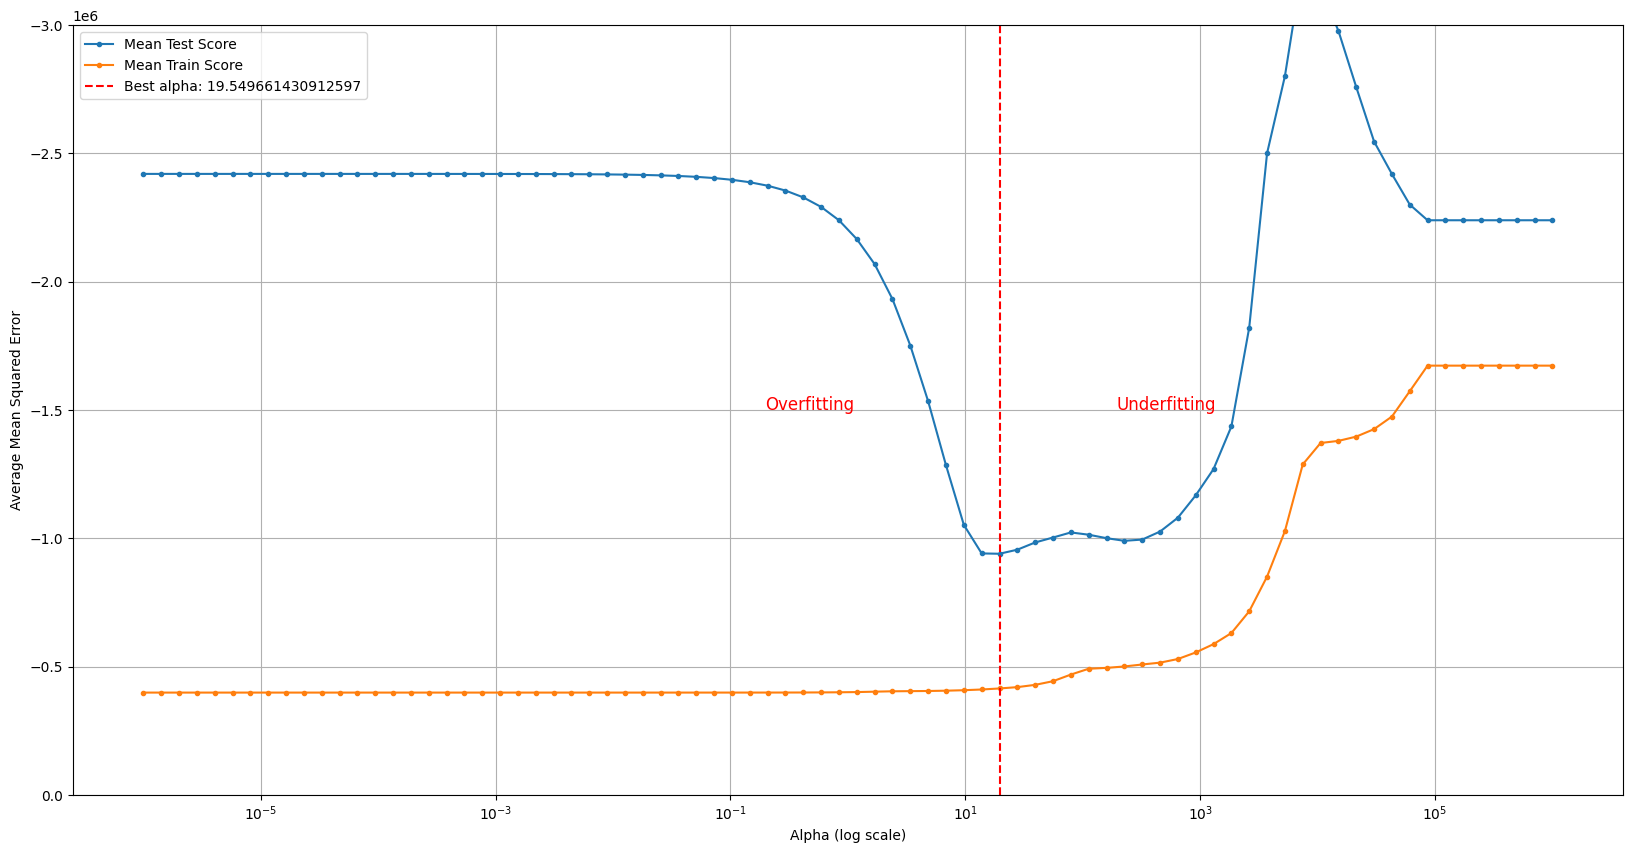

In [113]:
best_alpha_lasso = lasso_search_cv.best_params_["alpha"]

fig, ax = plt.subplots(1, figsize=(20,10))
ax.plot(param_grid["alpha"], lasso_cv_results["mean_test_score"], marker = ".",label = "Mean Test Score")
ax.plot(param_grid["alpha"], lasso_cv_results["mean_train_score"], marker = ".",label = "Mean Train Score")
ax.set_xscale("log")
ax.set_ylim([0, -3e6])
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Average Mean Squared Error")
ax.legend(["Mean Test Score", "Mean Train Score"], loc="best")
ax.grid()
if best_alpha_ridge is not None:
    ax.axvline(best_alpha_lasso, color="red", linestyle="--", label=f"Best alpha: {best_alpha_lasso}")
    ax.text(best_alpha_lasso/100, -1.5e6, "Overfitting", color="red", fontsize=12)
    ax.text(best_alpha_lasso*10, -1.5e6, "Underfitting", color="red", fontsize=12)
    ax.legend()

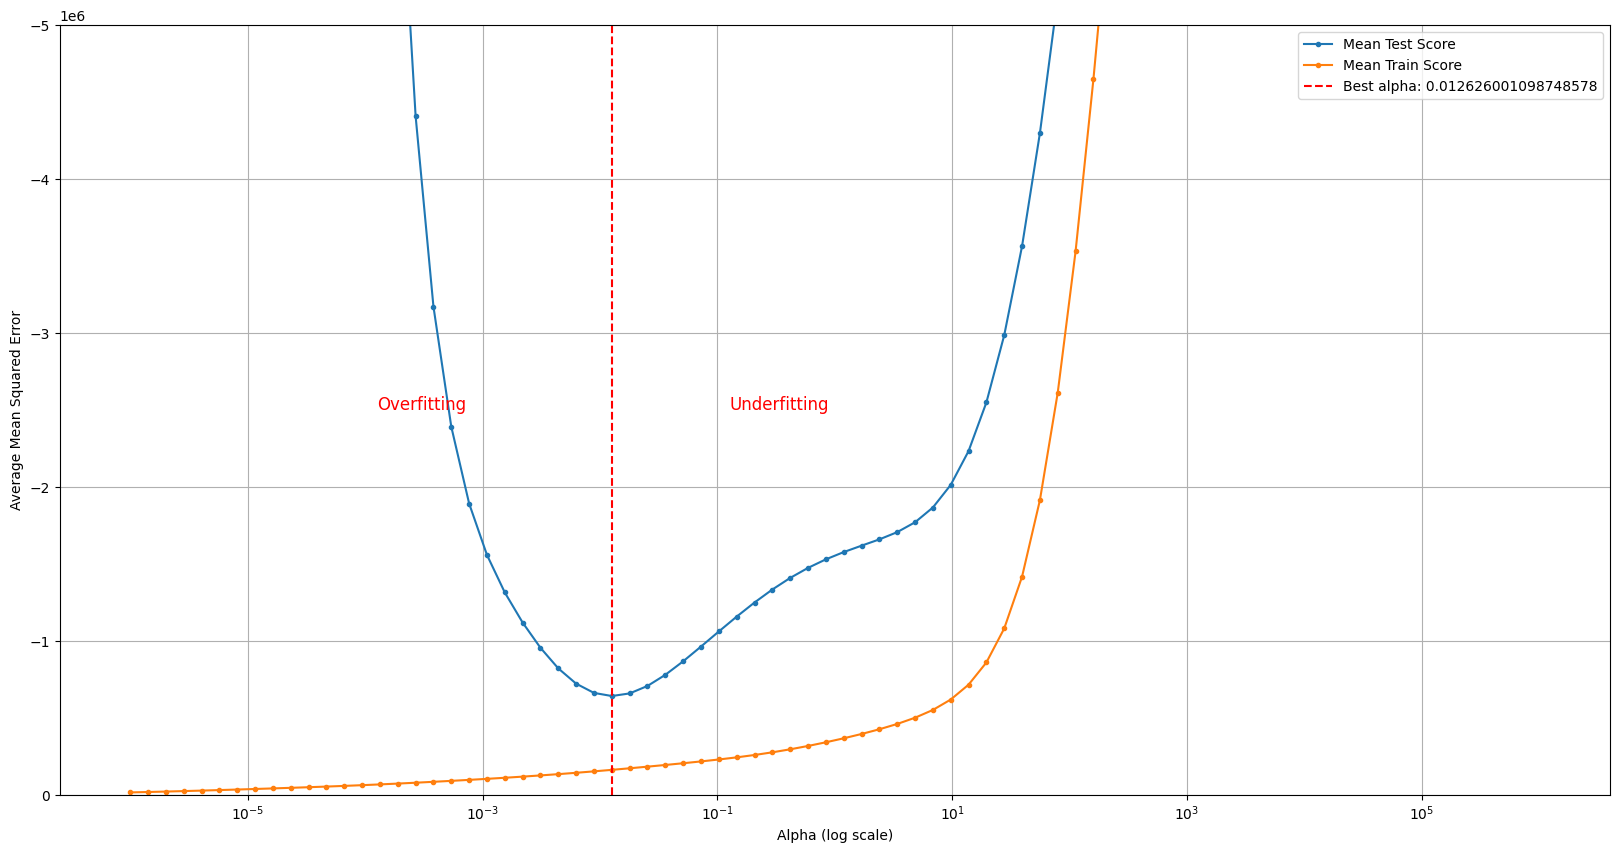

In [118]:
# Kernel Ridge wird für bestes gamma ausgewählt
best_gamma = kernelridge_search_cv.best_params_['gamma']    
kernelRidge_cv_results = kernelridge_cv_results[kernelridge_cv_results['param_gamma'] == best_gamma]
best_alpha_kernelridge = kernelridge_search_cv.best_params_["alpha"]

fig, ax = plt.subplots(1, figsize=(20,10))
ax.plot(param_grid["alpha"], kernelRidge_cv_results["mean_test_score"], marker = ".",label = "Mean Test Score")
ax.plot(param_grid["alpha"], kernelRidge_cv_results["mean_train_score"], marker = ".",label = "Mean Train Score")
ax.set_xscale("log")
ax.set_ylim([0, -5e6])
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Average Mean Squared Error")
ax.legend(["Mean Test Score", "Mean Train Score"], loc="best")
ax.grid()
if best_alpha_ridge is not None:
    ax.axvline(best_alpha_kernelridge, color="red", linestyle="--", label=f"Best alpha: {best_alpha_kernelridge}")
    ax.text(best_alpha_kernelridge/100, -2.5e6, "Overfitting", color="red", fontsize=12)
    ax.text(best_alpha_kernelridge*10, -2.5e6, "Underfitting", color="red", fontsize=12)
    ax.legend()

Verglecih der einzelnen Modelle

In [124]:

best_scores = {
    "Ridge Regression": ridge_search_cv.best_score_,
    "Lasso Regression": lasso_search_cv.best_score_,
    "Kernel Ridge Regression": kernelridge_search_cv.best_score_
}

for model_name, score in best_scores.items():
    print(f"{model_name} best mean test score: {score:.4f}")

best_model_name = max(best_scores, key=best_scores.get)
print(f"Best model is {best_model_name}")


Ridge Regression best mean test score: -992001.7580
Lasso Regression best mean test score: -940407.3192
Kernel Ridge Regression best mean test score: -643509.7500
Best model is Kernel Ridge Regression


Ploten der Koeffizienten des besten Modells

In [ ]:
best_model = KernelRidge(kernel="rbf", alpha=best_alpha_kernelridge, gamma=best_gamma)
best_model.fit(X_train_final, y_train)

In [147]:
X_train_final

,season_1,season_2,season_3,season_4,yr_0,yr_1,mnth_1,mnth_2,mnth_3,mnth_4,...,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit,temp,atemp,hum,windspeed
0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.666667,0.405300,0.432426,0.828620,0.316173
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.666667,0.428041,0.420669,0.715771,0.489768
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.333333,0.231243,0.225242,0.449638,0.489314
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.333333,0.235525,0.252257,0.607131,0.315877
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.333333,0.267270,0.272650,0.449313,0.368303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.333333,0.621197,0.623863,0.583548,0.870138
433,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.666667,0.483807,0.472214,0.418594,0.817399
434,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.333333,0.338567,0.330323,0.360326,0.444860
435,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.333333,0.425993,0.427722,0.490444,0.438627


C:\Users\Paul Bichl\AppData\Local\Temp\ipykernel_15800\1381709983.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(result.importances.T, vert=True, labels=X_train_final.columns)


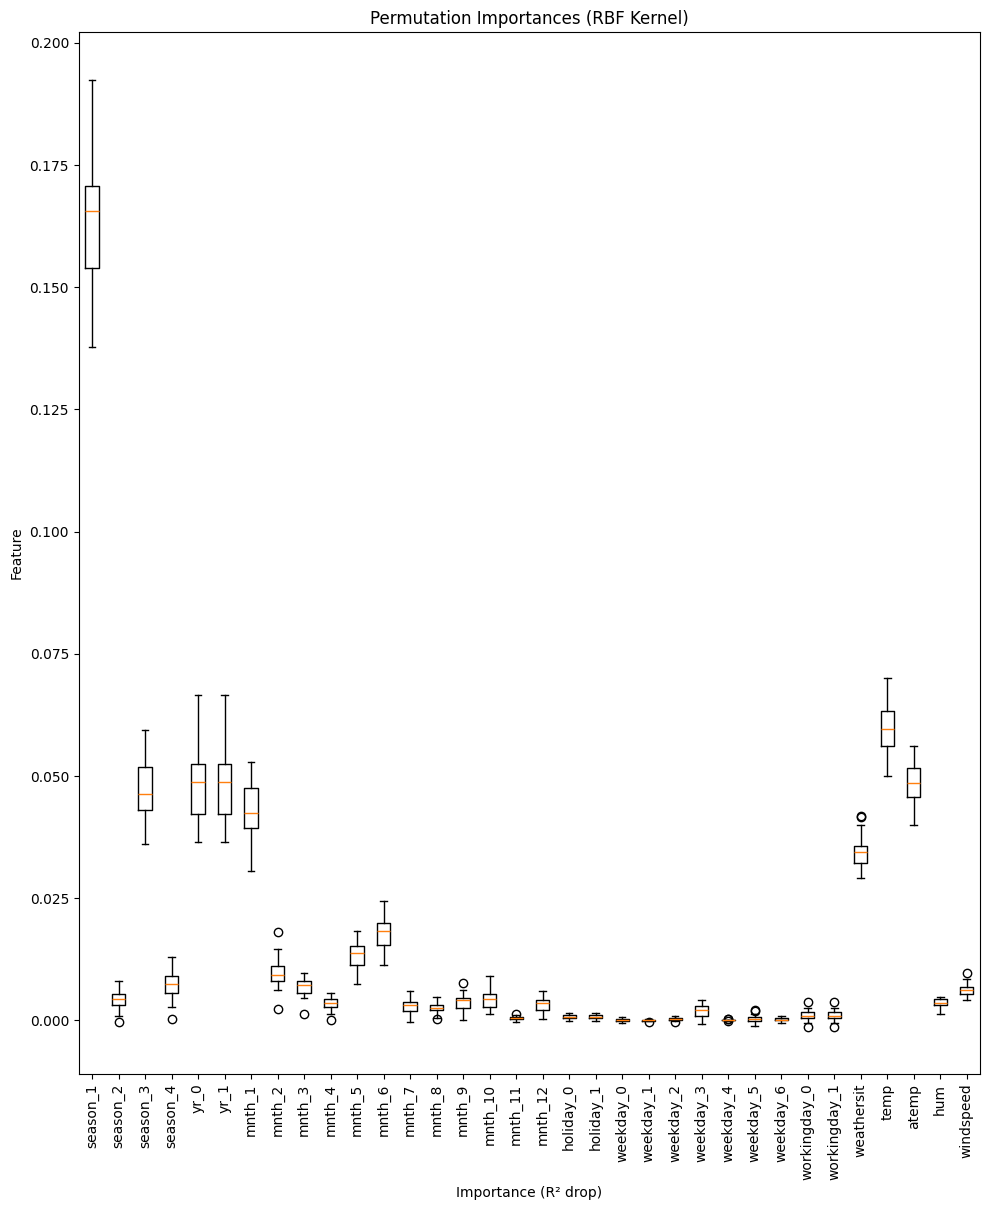

In [148]:
# GPT, das war 
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(best_model, X_train_final, y_train, n_repeats=30, random_state=42, scoring='r2')

# Plot: features on Y-axis, importance on X-axis (no sorting)
fig, ax = plt.subplots(figsize=(10, len(X_train_final.columns) * 0.3 + 2))
ax.boxplot(result.importances.T, vert=True, labels=X_train_final.columns)
ax.set_title("Permutation Importances (RBF Kernel)")
ax.set_xlabel("Importance (R² drop)")
ax.set_ylabel("Feature")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Vorhersage des besten Modells

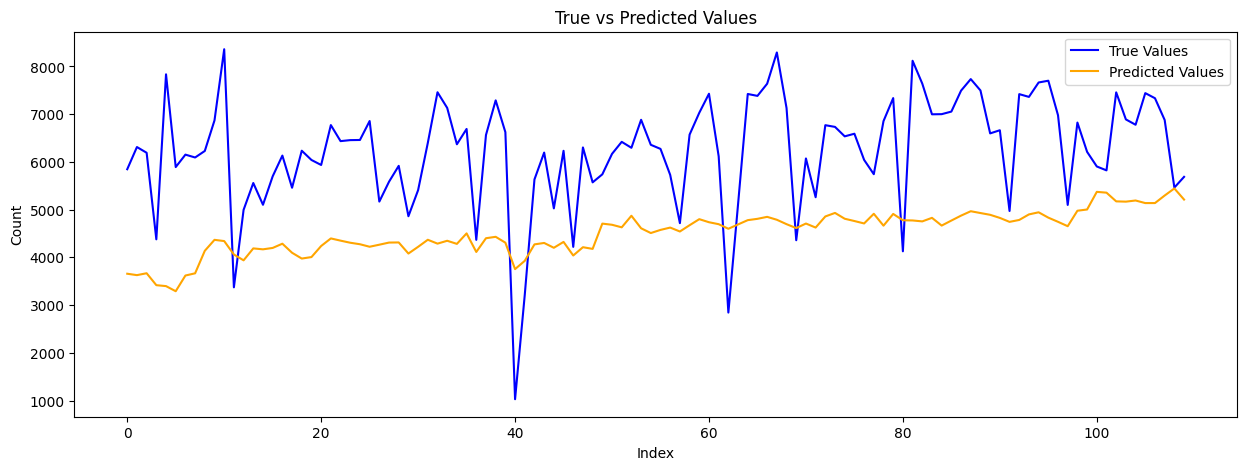

In [152]:
y_pred = best_model.predict(X_vaild_final)

fig, ax = plt.subplots(1, figsize=(15, 5))
ax.plot(y_valid.values, label="True Values", color="blue")
ax.plot(y_pred, label="Predicted Values", color="orange")
ax.set_xlabel("Index")
ax.set_ylabel("Count")
ax.set_title("True vs Predicted Values")
ax.legend()
plt.show()


In [153]:
mse = np.mean((y_valid - y_pred) ** 2)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 4108935.1580


Vorbereitung auf Testdatensatz 

In [ ]:
test_data = pd.read_csv("./data/Bike_rental_test.csv")


In [ ]:
columns = [ 'instant', 'season', 'yr', 'mnth', 'holiday',
       'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum',
       'windspeed']

X_test = test_data[columns] #training features
y_test = test_data["cnt"] #training features

# Preprocessing
X_test_enc = enc.transform(X_test[enc_features])
X_test_enc = pd.DataFrame(X_test_enc, columns= enc.get_feature_names_out(enc_features))

X_test_scale = scaler.transform(X_test[num_features])
X_test_scale = pd.DataFrame(X_test_scale, columns=num_features)

X_test_final = pd.concat((X_test_enc, X_test_scale), axis=1)

In [ ]:
y_test_pred = best_model.predict(X_test_final)


In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(y_test.values, label="True Values", color="blue")
plt.plot(y_test_pred, label="Predicted Values", color="orange")
plt.xlabel("Index")
plt.ylabel("Count")
plt.title("True vs Predicted Values")
plt.legend()
plt.show()


Modell speichern

In [154]:
import joblib as joblib # Save Model, 
joblib.dump(best_model,'Bichl_UE2_ML_Model.joblib') 


['Bichl_UE2_ML_Model.joblib']